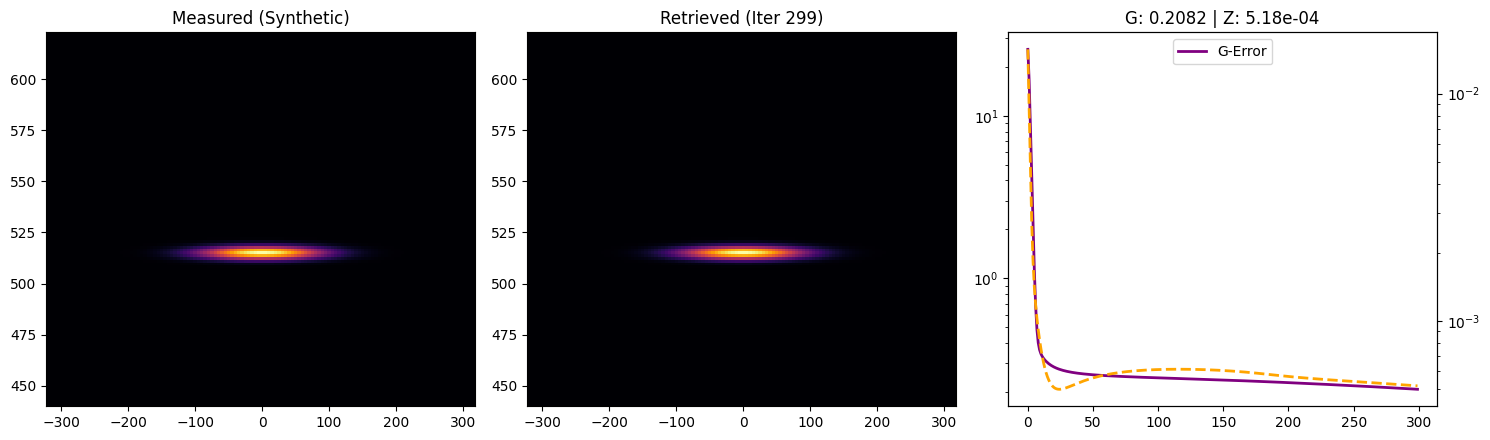

Retrieval Complete.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# --- 1. SETUP SYNTHETIC TRACE (GROUND TRUTH) ---
N = 128
dt = 5.0 # fs
t_grid = (np.arange(N) - N//2) * dt
c = 299.792458 # nm/fs
lam0_nm = 515.0

# Define ground truth physics (150fs FWHM, 1200fs^2 GDD)
true_fwhm = 150.0
true_gdd = 1500.0
sigma = true_fwhm / (2 * np.sqrt(2 * np.log(2)))
alpha_true = true_gdd / (4 * sigma**4)

# Create True E-field and Measured Amplitude (A_meas)
E_true = np.exp(-t_grid**2 / (2 * sigma**2)) * np.exp(1j * alpha_true * t_grid**2)
E_true /= np.max(np.abs(E_true))

Sig_t_sim = np.zeros((N, N), dtype=np.complex128)
for i in range(N):
    shift = i - N//2
    Sig_t_sim[i, :] = E_true * np.roll(E_true, shift)

Sig_w_sim = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(Sig_t_sim, axes=1), axis=1), axes=1)
A_meas = np.sqrt(np.abs(Sig_w_sim)**2) # This is our "Target" data

# Define Wavelength/Delay axes for plotting
dw = (2 * np.pi) / (N * dt)
w0 = (2 * np.pi * c) / lam0_nm
w_grid = (np.arange(N) - N//2) * dw + w0
lambda_grid = (2 * np.pi * c) / w_grid
delay_grid = t_grid

# --- 2. INITIALIZE GUESS ---
E_guess = (1.0 / np.cosh(t_grid / true_fwhm)).astype(np.complex128)
E_guess += 0.05 * (np.random.randn(N) + 1j * np.random.randn(N)) # Add noise to seeds
E_guess /= np.max(np.abs(E_guess))

# --- 3. YOUR GP ALGORITHM LOOP ---
n_iter = 300 # Reduced for the demo, but 300 is fine
errors = []
z_errors = []

print("Starting Retrieval Loop...")
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax2_z = ax[2].twinx()

for k in range(n_iter):
    # Generate Signal Matrix Sig(tau, t) for SHG 
    Sig_t = np.zeros((N, N), dtype=np.complex128)
    for i in range(N):
        shift = i - N//2
        E_shifted = np.roll(E_guess, shift)
        Sig_t[i, :] = E_guess * E_shifted 
        
    Sig_w = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(Sig_t, axes=1), axis=1), axes=1)

    # Calculate G-Error
    current_amp = np.abs(Sig_w)
    I_meas = A_meas**2
    I_rec = current_amp**2
    scale_G = np.sum(I_meas * I_rec) / (np.sum(I_rec**2) + 1e-10)
    err = np.sqrt(np.mean((I_meas - scale_G * I_rec)**2))
    errors.append(err)

    # Apply Experimental Constraint
    current_amp[current_amp < 1e-10] = 1e-10 
    Sig_w_new = Sig_w * (A_meas / current_amp)

    # Inverse FFT back to Time Domain
    Sig_t_new = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(Sig_w_new, axes=1), axis=1), axes=1)

    # Update Electric Field (SHG Projection)
    E_new_num = np.zeros(N, dtype=np.complex128)
    E_new_den = np.zeros(N, dtype=np.float64)
    for i in range(N):
        shift = i - N//2
        E_shifted_conj = np.conj(np.roll(E_guess, shift))
        E_new_num += Sig_t_new[i, :] * E_shifted_conj
        E_new_den += np.abs(E_shifted_conj)**2
        
    E_new = E_new_num / (E_new_den + 1e-10)
    E_new /= np.max(np.abs(E_new))
    
    # Z-Error Calculation
    Sig_t_physical = np.zeros((N, N), dtype=np.complex128)
    for i in range(N):
        shift = i - N//2
        Sig_t_physical[i, :] = E_new * np.roll(E_new, shift)
    I_math = np.abs(Sig_t_new)**2
    I_phys = np.abs(Sig_t_physical)**2
    scale_Z = np.sum(I_math * I_phys) / (np.sum(I_phys**2) + 1e-10)
    z_err = np.sqrt(np.mean((I_math - scale_Z * I_phys)**2))
    z_errors.append(z_err)

    # Momentum update
    E_guess = 0.5 * E_new + 0.5 * E_guess

    # Live Plotting Logic
    if k % 10 == 0 or k == n_iter - 1:
        ax[0].clear()
        ax[1].clear()
        ax[2].clear()
        ax2_z.clear()
        
        ax[0].pcolormesh(delay_grid, lambda_grid, (A_meas**2).T, cmap='inferno', shading='auto')
        ax[0].set_title("Measured (Synthetic)")
        
        Rec_trace = np.abs(Sig_w)**2
        Rec_trace /= np.max(Rec_trace) 
        ax[1].pcolormesh(delay_grid, lambda_grid, Rec_trace.T, cmap='inferno', shading='auto')
        ax[1].set_title(f"Retrieved (Iter {k})")
        
        ax[2].plot(errors, color='purple', linewidth=2, label='G-Error')
        ax[2].set_yscale('log')
        ax2_z.plot(z_errors, color='orange', linewidth=2, linestyle='--', label='Z-Error')
        ax2_z.set_yscale('log')
        ax[2].legend(loc='upper center')
        ax[2].set_title(f"G: {err:.4f} | Z: {z_err:.2e}")
        
        plt.tight_layout()
        clear_output(wait=True)
        display(fig)

plt.close(fig)
print("Retrieval Complete.")

NOTE: Sign flip detected (SHG Ambiguity). Correcting for comparison...


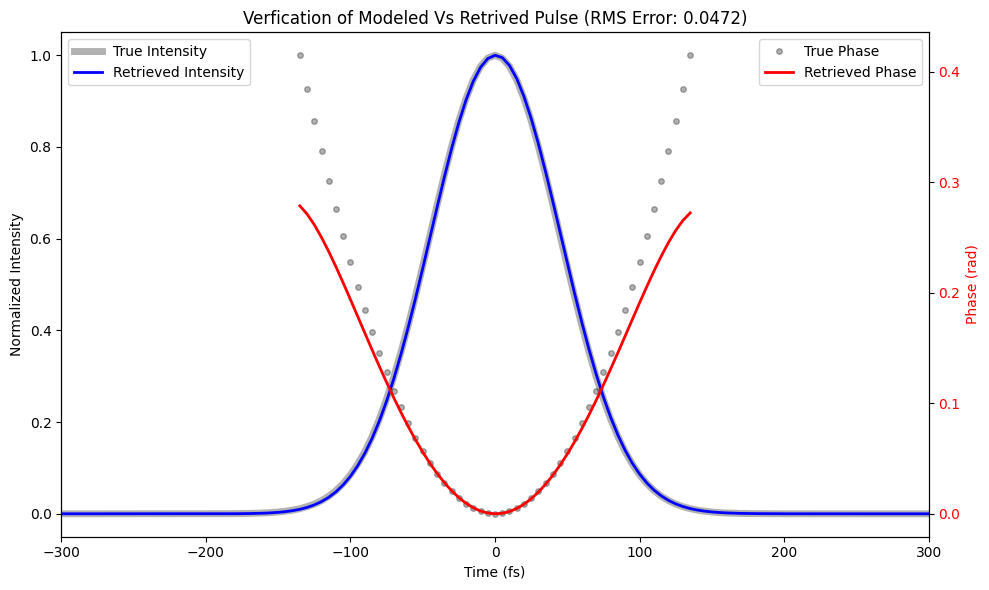

Phase Retrieval RMS Error: 0.0472 rad
STATUS: SUCCESS - The algorithm has recovered the phase with high fidelity.


In [24]:


# 1. Process Ground Truth
peak_idx_true = np.argmax(np.abs(E_true)**2)
true_phase = np.unwrap(np.angle(E_true))
true_phase -= true_phase[peak_idx_true]

# Helper function to align pulse and extract phase
def align_and_process(E_retrieved):
    # Align peak to the ground truth peak using a circular shift
    peak_idx_ret = np.argmax(np.abs(E_retrieved)**2)
    shift_amount = peak_idx_true - peak_idx_ret
    E_aligned = np.roll(E_retrieved, shift_amount)
    
    # Calculate phase centered at the peak
    phase = np.unwrap(np.angle(E_aligned))
    phase -= phase[peak_idx_true] 
    
    return E_aligned, phase

# 2. Process Direct Retrieval
E_dir, phase_dir = align_and_process(E_guess)

# 3. Process Ambiguous Counterpart: E*(-t)
E_ambig, phase_ambig = align_and_process(np.conj(E_guess[::-1]))

# 4. Create evaluation mask (where intensity > 1%)
mask = np.abs(E_true)**2 > 0.01 

# 5. Calculate RMS errors for both possibilities
err_dir = np.sqrt(np.mean((true_phase[mask] - phase_dir[mask])**2))
err_ambig = np.sqrt(np.mean((true_phase[mask] - phase_ambig[mask])**2))

# 6. Select the best match
if err_ambig < err_dir:
    print("NOTE: Sign flip detected (SHG Ambiguity). Correcting for comparison...")
    final_E = E_ambig
    final_phase = phase_ambig
    final_error = err_ambig
else:
    final_E = E_dir
    final_phase = phase_dir
    final_error = err_dir

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Plot Intensities
ax1 = plt.gca()
ax1.plot(t_grid, np.abs(E_true)**2, 'k-', alpha=0.3, linewidth=5, label='True Intensity')
ax1.plot(t_grid, np.abs(final_E)**2, 'b-', linewidth=2, label='Retrieved Intensity')
ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Normalized Intensity")
ax1.set_xlim([-300, 300])
ax1.legend(loc='upper left')

# Plot Phases
ax2 = ax1.twinx()
ax2.plot(t_grid[mask], true_phase[mask], 'ko', markersize=4, alpha=0.3, label='True Phase')
ax2.plot(t_grid[mask], final_phase[mask], 'r-', linewidth=2, label='Retrieved Phase')
ax2.set_ylabel("Phase (rad)", color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right')

plt.title(f"Verfication of Modeled Vs Retrived Pulse (RMS Error: {final_error:.4f})")

plt.tight_layout()
plt.show()

# --- Quantitative Pass/Fail ---
print(f"Phase Retrieval RMS Error: {final_error:.4f} rad")
if final_error < 0.1:
    print("STATUS: SUCCESS - The algorithm has recovered the phase with high fidelity.")
else:
    print("STATUS: WARNING - Phase discrepancy detected. Check for stagnation or grid mismatch.")

In [26]:

def get_fwhm(axis, intensity):
    """Helper function to calculate Full-Width at Half-Maximum."""
    half_max = np.max(intensity) / 2.0
    above_half = np.where(intensity >= half_max)[0]
    if len(above_half) > 0:
        return np.abs(axis[above_half[-1]] - axis[above_half[0]])
    return 0.0

# 1. Temporal FWHM
I_true_t = np.abs(E_true)**2
I_ret_t = np.abs(final_E)**2 # Using final_E from the ambiguity correction

fwhm_t_true = get_fwhm(t_grid, I_true_t)
fwhm_t_ret = get_fwhm(t_grid, I_ret_t)

# 2. Spectral FWHM
# Calculate spectra
E_w_true = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(E_true)))
E_w_ret = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(final_E)))

I_true_w = np.abs(E_w_true)**2
I_ret_w = np.abs(E_w_ret)**2

# Frequency axis in Hz (nu = w / 2pi)
nu_grid = w_grid / (2 * np.pi) 

# Note: nu_grid is in PHz (1e15 Hz) because t_grid is in fs (1e-15 s)
fwhm_nu_true = get_fwhm(nu_grid, I_true_w)
fwhm_nu_ret = get_fwhm(nu_grid, I_ret_w)

# 3. Time-Bandwidth Product (TBP)
tbp_true = fwhm_t_true * fwhm_nu_true
tbp_ret = fwhm_t_ret * fwhm_nu_ret

# 4. Final FROG Error Percentage
# We use the final 'err' value from your loop, converted to a percentage
final_frog_error_percent = errors[-1] * 100 

# --- PRINT RESULTS ---
print("\n" + "="*45)
print("       FINAL PHYSICAL VERIFICATION")
print("="*45)
print(f"Final FROG Trace Error: {final_frog_error_percent:.4f}%")
print("-" * 45)
print(f"{'Metric':<20} | {'Ground Truth':<10} | {'Retrieved':<10}")
print("-" * 45)
print(f"{'Time FWHM (fs)':<20} | {fwhm_t_true:>10.2f} | {fwhm_t_ret:>10.2f}")
print(f"{'Freq FWHM (PHz)':<20} | {fwhm_nu_true:>10.4f} | {fwhm_nu_ret:>10.4f}")
print(f"{'TBP (\u0394t \u0394\u03BD)':<20} | {tbp_true:>10.3f} | {tbp_ret:>10.3f}")
print("="*45)

SyntaxError: f-string expression part cannot include a backslash (3862432892.py, line 49)